In [1]:
from uqpylab import sessions
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
# from Switch_model import MalCoA_switch
# from Switch_model import A
from Switch_model1 import model
#from Switch_model1 import oscillation_metric

/Users/andrea/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Start the session
mySession = sessions.cloud()
# (Optional) Get a convenient handle to the command line interface
uq = mySession.cli
# Reset the session
mySession.reset()

 uqpylab.sessions :: INFO     :: This is UQ[py]Lab, version 1.0, running on https://uqcloud.ethz.ch. 
                                 UQ[py]Lab is free software, published under the open source BSD 3-clause license.
                                 To request special permissions, please contact:
                                  - Stefano Marelli (marelli@ibk.baug.ethz.ch).
                                 A new session (9b268b3ba59748e7a669038733d5109c) started.
 uqpylab.sessions :: INFO     :: Reset successful.


In [3]:
ModelOpts = {
    'Type': 'Model', 
    'ModelFun':'Switch_model1.model'
}
myModel = uq.createModel(ModelOpts)

In [4]:
InputOpts = {
    'Marginals': [
        # D is fixed at 0.127851 in MalCoA_ODE1.MalCoA_switch
        {
            'Name': 'D', # cell growth-associated FapR production rate constant (constitutive)
            'Type': 'Uniform',
            'Parameters': [0.12, 0.5] # % 
        },
        # {
        #     'Name': 'alpha1', # cell growth-associated FapR production rate constant (constitutive)
        #     'Type': 'Uniform',
        #     'Parameters': [0.4, 1.2] # % 
        # },
        # {
        #     'Name': 'alpha2', # cell growth-associated FAS production rate constant (leaky expression)
        #     'Type': 'Uniform',
        #     'Parameters': [0.025, 0.075] # %
        # },
        # {
        #     'Name': 'K1',  # Malonyl-CoA inhibitory (dissociation) constant
        #     'Type': 'Uniform',
        #     'Parameters': [1, 3]
        # },
        # {
        #     'Name': 'K2',  # Mal-CoA and FapR saturation constant
        #     'Type': 'Uniform',
        #     'Parameters': [2.5, 7.5]
        # },
        {
            'Name': 'K3',  # dissociation rate constant of free FapR toward fapO in the FAS operon (to repress FAS transcription)
            'Type': 'Uniform',
            'Parameters': [1, 3]
        },
        # {
        #     'Name': 'K4',  # dissociation rate constant of free FapR toward UAS in the ACC operon (to activate ACC transcription)
        #     'Type': 'Uniform',
        #     'Parameters': [1, 3]
        # },
        # {
        #     'Name': 'K5',  # acetyl-CoA saturation (Michaelis) constant toward ACC
        #     'Type': 'Uniform',
        #     'Parameters': [0.25, 0.75]
        # },
        # {
        #     'Name': 'K6',  # glucose saturation (Michaelis) constant toward glycolytic pathway
        #     'Type': 'Uniform',
        #     'Parameters': [0.25, 0.75]
        # },
        # {
        #     'Name': 'alpha3', # cell growth-associated ACC production rate constant (leaky expression)
        #     'Type': 'Uniform',
        #     'Parameters': [0.025, 0.075] # 
        # },
        # {
        #     'Name': 'alpha4', # cell growth-associated PDH production rate constant (constitutive expression)
        #     'Type': 'Uniform',
        #     'Parameters': [0.4, 1.2] # 
        # },
        {
            'Name': 'beta1', # non cell growth-associated FAS production rate (regulated expression)
            'Type': 'Uniform',
            'Parameters': [0.25, 0.75] # 
        },
        # {
        #     'Name': 'beta2', # non cell growth-associated ACC production rate (regulated expression)
        #     'Type': 'Uniform',
        #     'Parameters': [1, 3] # 
        # },
        # { 
        #     'Name': 'k1',  # FapR-inactivating rate constant due to the formation of MalCoA-FapR complex
        #     'Type': 'Uniform',
        #     'Parameters': [0.25, 0.75]
        # },
        {
            'Name': 'k2',  # FA (fatty acids) production rate constant from Mal-CoA catalyzed by FAS
            'Type': 'Uniform',
            'Parameters': [0.3, 0.9]
        },
        # {
        #     'Name': 'k3',  # malonyl-CoA production rate constant from acetyl-CoA catalyzed by ACC
        #     'Type': 'Uniform',
        #     'Parameters': [1, 3]
        # },
        # {
        #     'Name': 'k4',  # acetyl-CoA production rate constant from glycolysis catalyzed by PDH
        #     'Type': 'Uniform',
        #     'Parameters': [1, 3]
        # },
        {
            'Name': 'S0',  # glucose concentration in the feeding stream
            'Type': 'Uniform',
            'Parameters': [25, 60]
        },
        {
            'Name': 'YPS1',  # malonyl-CoA to fatty acids conversion yield
            'Type': 'Uniform',
            'Parameters': [0.2, 0.6]
        },
        {
            'Name': 'YXS',  # glucose to biomass conversion yield
            'Type': 'Uniform',
            'Parameters': [0.3, 0.9]
        },
        {
            'Name': 'YPS2',  # glucose to acetyl-CoA conversion yield
            'Type': 'Uniform',
            'Parameters': [0.9, 2.7]
        },
        {
            'Name': 'mu_max', # Maximum specific growth rate
            'Type': 'Uniform',
            'Parameters': [1.1, 3.3] # % (1/hr)
        # },
        # {
        #     'Name': 'KS',  # Monod constant for glucose
        #     'Type': 'Uniform',
        #     'Parameters': [0.38, 1.13]
        # },
        # {
        #     'Name': 'Km',  # Malonyl-CoA saturation (Michaelis) constant toward FAS
        #     'Type': 'Uniform',
        #     'Parameters': [0.25, 0.75]
        }
    ]
}


In [5]:
myInput = uq.createInput(InputOpts)

In [6]:
#K1=2; K2=5; K3=2; K4=2; K5=0.5; K6=0.5;
#alpha3=0.05; alpha4=0.8;
#beta1=0.5; beta2=2.0; m=4; n=4; p=4; q=4; r=4; u=4; 
#k1=0.5; k2=0.6; k3=2; k4=2; X0=0; S0=45; Y_XS=0.6; Y_PS1=0.4; Y_PS2=1.8; mu_max=2.2;
#K_S=0.75; K_m=0.5;
uq.rng (100, 'twister') # Set the random seed for reproducibility
X_input = uq.getSample(myInput, 100, Method='MC') # Draw 1000 samples from the input distribution using Monte Carlo sampling

In [6]:
# Morris 
MorrisSensOpts = {
    'Type': 'Sensitivity',
    'Method': 'Morris',
    'Morris':{
        'Cost': 1e3
    }
}
MorrisAnalysis=uq.createAnalysis(MorrisSensOpts)

uq.print(MorrisAnalysis)
uq.display(MorrisAnalysis)

 uqpylab.sessions :: INFO     :: Received intermediate compute request, function: Switch_model1.model.
 uqpylab.sessions :: INFO     :: Carrying out local computation...
 uqpylab.sessions :: INFO     :: Local computation complete.
 uqpylab.sessions :: INFO     :: Starting transmission of intermediate compute results ((1000, 1))...
 uqpylab.sessions :: INFO     :: Intermediate compute results sent.
--------------------------------------------------
     Morris sensitivity indices:
--------------------------------------------------
       D           alpha1      alpha2      K1          K2          K3          K4          K5          K6          alpha3      alpha4      beta1       beta2       k1          k2          k3          k4          S0          YPS1        YXS         YPS2        mu_max      KS          Km          
mu:    -5.307197   -0.828199   0.451733    -0.425161   -0.190003   2.176088    -0.776668   -0.014682   -0.941923   0.032176    1.216123    1.040804    0.834229    0.443

[Figure({
     'data': [{'line': {'color': 'black', 'width': 2},
               'mode': 'lines',
               'showlegend': False,
               'type': 'scatter',
               'x': [-11.267221286626851, 5.005003050847933],
               'y': [0, 0]},
              {'line': {'color': 'black', 'width': 2},
               'mode': 'lines',
               'showlegend': False,
               'type': 'scatter',
               'x': [0, 0],
               'y': [-2.659008097789138, 20.385728749716726]},
              {'customdata': [[['μ'], ['σ']]],
               'hovertemplate': ('<b>Input Variable: %{text}</b>' ... 'stomdata[1]}</b>: %{y:.5g}<br>'),
               'marker': {'color': 'rgb(0, 76, 153)'},
               'mode': 'markers',
               'name': 'D',
               'text': [D],
               'textfont': {'color': 'rgb(0, 76, 153)'},
               'textposition': 'top center',
               'type': 'scatter',
               'x': [-5.307197400866821],
               'y':

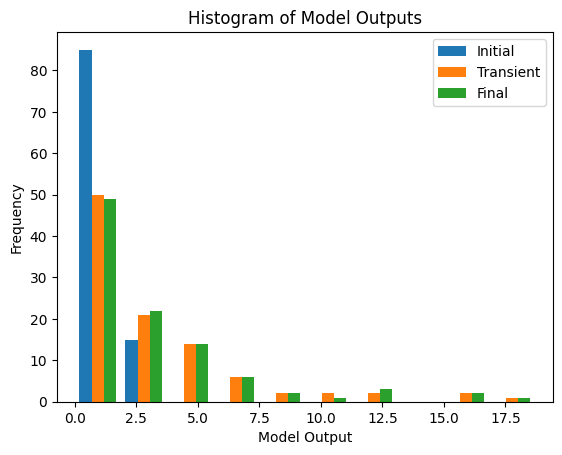

In [10]:

plt.hist(Y_test, bins=10) # Plot a histogram of the model outputs
plt.xlabel('Model Output')
plt.ylabel('Frequency')
plt.title('Histogram of Model Outputs')
plt.legend(["Initial","Transient","Final"])
plt.show()

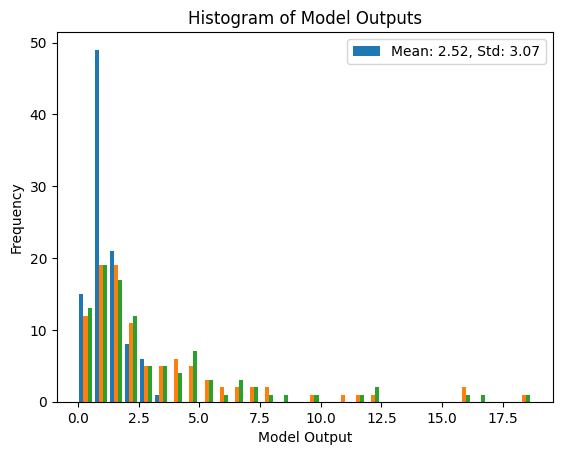

In [8]:
# Y test
Y_test = uq.evalModel(myModel, X_input) # Evaluate the model on the input samples
plt.hist(Y_test, bins=30) # Plot a histogram of the model outputs
plt.xlabel('Model Output')
plt.ylabel('Frequency')
plt.title('Histogram of Model Outputs')
plt.legend(['Mean: {:.2f}, Std: {:.2f}'.format(np.mean(Y_test), np.std(Y_test))])
plt.show()

## Evaluate oscillation 
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from MalCoA_ODE1 import MalCoA_switch
from Switch_model1 import oscillation_metric

param_names = [
    "alpha1", "alpha2", "K1", "K2", "K3", "K4", "K5", "K6",
    "alpha3", "alpha4", "beta1", "beta2", "k1", "k2", "k3", "k4", "S0",
    "YPS1", "YXS", "YPS2", "mu_max", "KS", "Km"
]

# scores = []
oscillatory_flags = []

tspan = (0, 200)
t_eval = np.arange(0, 200, 1)
y0 = [1, 1, 1, 1, 0, 1, 1, 1, 1]

for i, params in enumerate(X_input):
    sol = solve_ivp(
        MalCoA_switch,
        tspan,
        y0,
        args=(params,),
        t_eval=t_eval,
        method="BDF",
        rtol=1e-6,
        atol=1e-9
    )

    if not sol.success or not np.isfinite(sol.y).all():
        # scores.append(np.nan)
        oscillatory_flags.append(False)
        continue

    oscillatory = oscillation_metric(sol.t, sol.y[4])

    # scores.append(score)
    oscillatory_flags.append(oscillatory)

# scores = np.array(scores)
oscillatory_flags = np.array(oscillatory_flags)
oscillating_params = X_input[oscillatory_flags]

oscillating_df = pd.DataFrame(oscillating_params, columns=param_names)
# oscillating_df["score"] = scores[oscillatory_flags]

oscillating_df
print(f"{oscillatory_flags.sum()} out of {len(X_input)} samples oscillated")

PCEOpts = {
    'Type': 'Metamodel',
    'MetaType': 'PCE',
    'Method': 'LARS',
    'FullModel': myModel['Name'],
    'Degree': 5,
    'ExpDesign': {
        'NSamples': 500}
}

myPCE = uq.createModel(PCEOpts)

YPCE_test = uq.evalModel(myPCE, X_input)

error=np.sqrt(np.mean((Y_test - YPCE_test)**2))
print(error)

plt.figure(figsize=(8, 5))
plt.plot(X_input, Y_test, "o-", label="Full model Y_test")
plt.plot(X_input, YPCE_test, label="PCE YPCE_test")
plt.xlabel("Input samples")
plt.ylabel("Model output")
# plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
SobolOpts = {
    'Type': 'Sensitivity',
    'Method': 'Sobol',
    'Sobol' : { # Specify the options for the Sobol sensitivity analysis

        'SampleSize' : 1e3,
        'Order' : 2
                }
}

In [ ]:
BorgonovoOpts = {
    "Type": "Sensitivity",
    "Method": "Borgonovo"
}
BorgonovoOpts["Borgonovo"] = {
    "SampleSize": 1e3
}
BorgonovoOpts["Borgonovo"]["NClasses"] = 20
BorgonovoAnalysis = uq.createAnalysis(BorgonovoOpts)
uq.print(BorgonovoAnalysis)
uq.display(BorgonovoAnalysis)

In [ ]:
print('BorgonovoAnalysis')

In [ ]:
BorgonovoResult = BorgonovoAnalysis['Results']
print(BorgonovoResult)

In [ ]:
SobolAnalysis = uq.createAnalysis(SobolOpts)
uq.print(SobolAnalysis)
uq.display(SobolAnalysis)

In [ ]:
SobolResults = SobolAnalysis['Results']
TotalSobolIndices = SobolResults['Total']
FirstOrderIndices = SobolResults['FirstOrder']
# print(TotalSobolIndices)
# print(FirstOrderIndices)
print(SobolResults)

In [ ]:
import pandas as pd
df = pd.DataFrame(TotalSobolIndices)
# df.columns = [f'Y<sub>{i+1}' for i in range(len(TotalSobolIndices[0]))]
df.index = SobolResults['VariableNames']

uq.display_bar(
    df, 
    xaxis_title='Input variable', 
    yaxis_title='S<sub>i</sub><sup>T', 
    title='Total Sobol\' indices', 
    showlegend=True, 
    width=900
)

df = pd.DataFrame(FirstOrderIndices)
df.columns = [f'Y<sub>{i+1}' for i in range(len(FirstOrderIndices[0]))]
df.index = SobolResults['VariableNames']

uq.display_bar(
    df, 
    xaxis_title='Input variable',
    yaxis_title='S<sub>i', 
    title='First-order Sobol\' indices', 
    showlegend=True, 
    width=900
)

import pandas as pd
results = SobolAnalysis['Results']

df_main = pd.DataFrame({
    'Variable': results['VariableNames'],
    'FirstOrder': results['FirstOrder'],
    'SecondOrder': results['SecondOrder'],
    'Total': results['Total'],
    'FactorIndex': results['FactorIndex'],
})

df_summary = pd.DataFrame([{
    'TotalVariance': results['TotalVariance'],
    'Cost': results['Cost'],
    'CoefficientBased': results['CoefficientBased'],
}])

df_interactions = pd.DataFrame({
    'Interaction': [f"x{i}-x{j}" for i, j in results['VarIdx'][1]],
    'Value': results['AllOrders'][1]
})

print("Main Effects:")
print(df_main)
print("\nSummary:")
print(df_summary)
print("\nInteractions:")
print(df_interactions)

mySession.quit()